In [3]:
from importlib import reload
import torch
import numpy as np
import time
import os
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): # x is the data array; a and b are center coordinates
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:1


In [11]:
global Nx,Ny,kk,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center,r
Nx = 1 # the number of sub-domains 
Ny = 1
M =800 # 800 works better than 400
Qx = 29 # the number of collocation pointss per sub-domain 
Qy = 29
R_m=20
Qs=16
af="Tanh"
eps=0.05
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89] # Multiple frequencies
center_true=np.array([0.71,0.5])
x_left=0.29
x_right=0.49
y_below=0.3
y_upper=0.7
r_true=0.2
tau_x_min=0 # Support domain
tau_x_max=1
tau_y_min=0
tau_y_max=1

b_x_min=-0.5 # On boundary Gamma
b_x_max=1.5
b_y_min=-0.5
b_y_max=1.5
number_gene=50 # Gauss points for data generation
number_appr=100 # Number of Gauss points for approximation
num_batches=1
model1 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
b_n=10# Samples per boundary side
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
cupy_device = device.index if device.type == "cuda" else 0
batch_number_rec_mea,mea=2,1
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b = -F_mea_b1 + F_mea_b2
F_mea_db_x1 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2 = -F_mea_db_x21 + F_mea_db_x22
F=inverse_solver.F(F_mea_b,F_mea_db_x1,F_mea_db_x2)
num_nn=1
choose="rec"


In [12]:
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model1,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


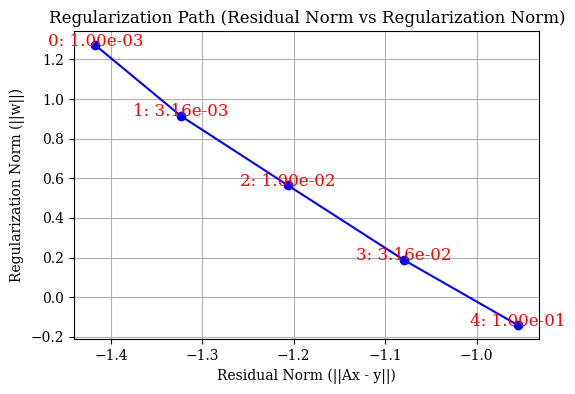

In [13]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

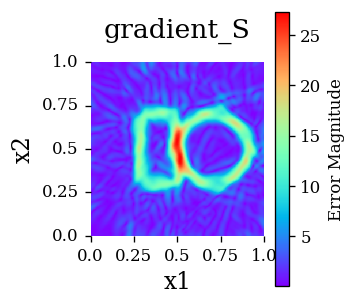

S_l_inf= 1.7327139007490502 S_L_2= 0.12644244643912916 S_l_2= 0.27994528285140136


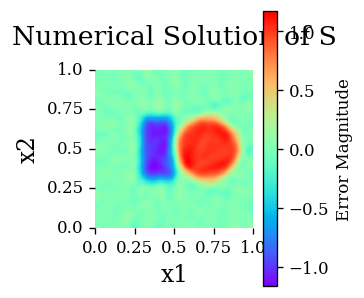

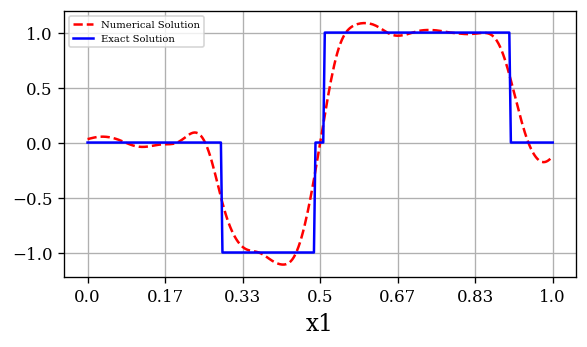

In [14]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2d.test(model1,[],[],M,Qx,Qy,w_store[:,4],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)


In [15]:
M=1600
model_1600 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model_1600,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


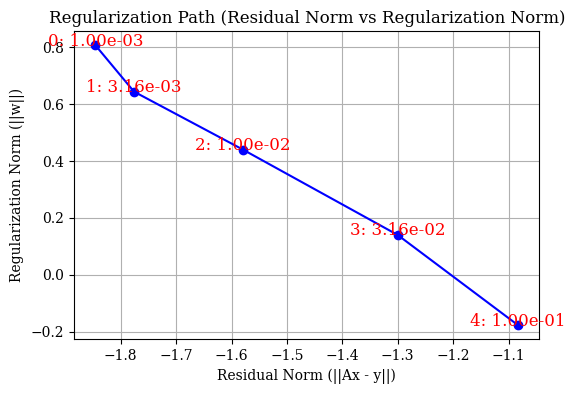

In [16]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

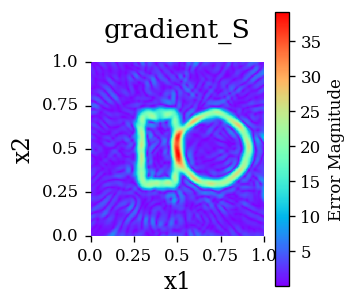

S_l_inf= 1.7639561066724219 S_L_2= 0.10409185442018855 S_l_2= 0.23046077048354896


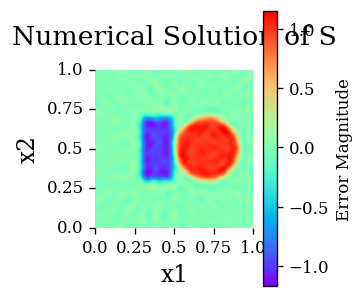

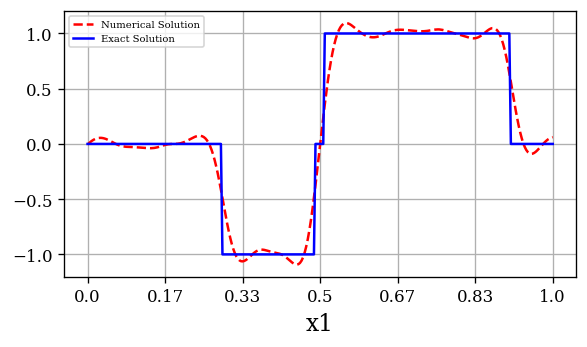

In [17]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2d.test(model_1600,[],[],M,Qx,Qy,w_store[:,3],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)


In [18]:
M=3200
model_3200 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model_3200,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


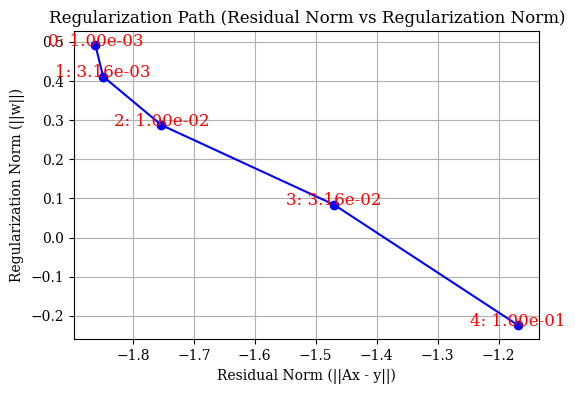

In [19]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

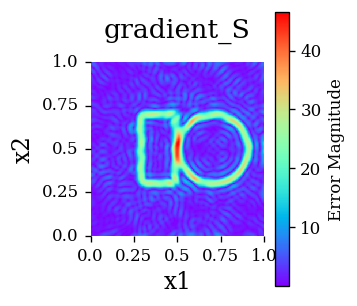

S_l_inf= 1.8306550900255485 S_L_2= 0.09675417288141877 S_l_2= 0.2142150445292247


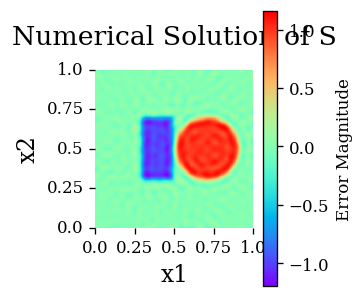

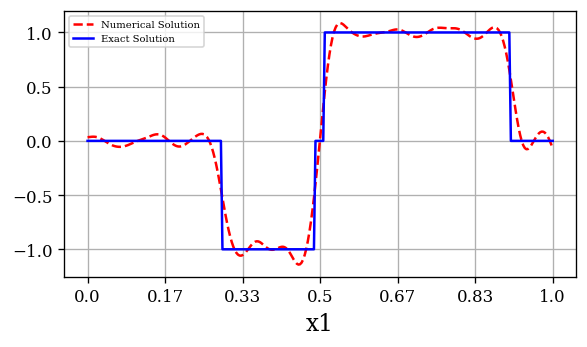

In [20]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2d.test(model_3200,[],[],M,Qx,Qy,w_store[:,2],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)


In [21]:
M=6400
model_6400 = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
num_batches_gauss=100 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model_6400,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,center_true,r_true,M,af,choose,mea,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


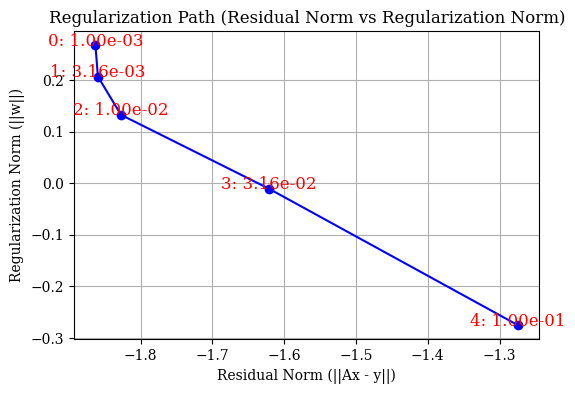

In [22]:
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)
lamb_regu=np.logspace(-3, -1, 5, endpoint = True) # 10-5, 10-4.5,..., 10+0.5, 10+1
res,reg_norm,w_store=inverse_solver.L_curve(all_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) # Solve first

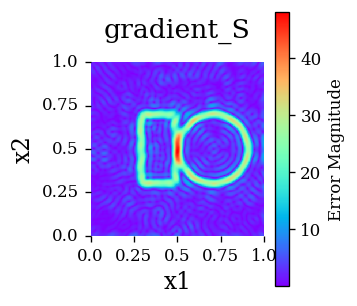

S_l_inf= 1.7994006528174582 S_L_2= 0.09445257174077132 S_l_2= 0.20911926854200635


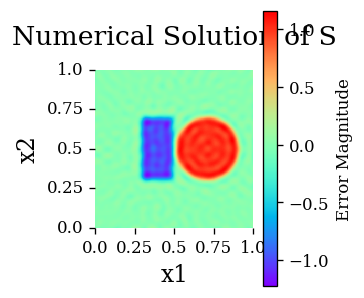

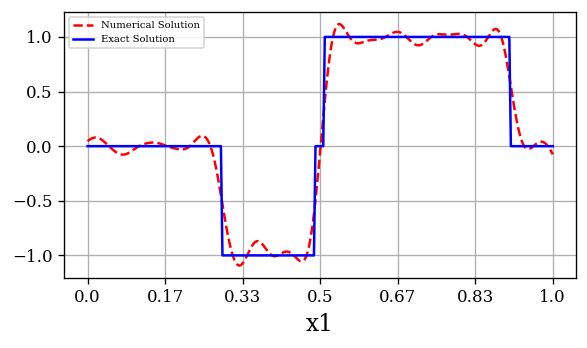

In [23]:
Qx=150
Qy=150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_S=error_general_2d.test(model_6400,[],[],M,Qx,Qy,w_store[:,2],af,[],[],True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)
